In [1]:
import geopandas as gpd
import pandas as pd

In [2]:
import sys, os
sys.path.append('..')

In [ ]:
import reverse_geocoder as rg
 
# 定义坐标点
coordinates = [(120.80935294000005, 24.000000000000057), (120.74595923000004, 24.000000000000057)]

coordinates_x = [(lat, lon) for lon, lat in coordinates]
 
# 执行逆向地理编码
results = rg.search(coordinates_x)
 
# 输出结果
for result in results:
    print(f"城市：{result['name']}, 国家：{result['cc']}")

[{'lat': '23.95908',
  'lon': '120.68516',
  'name': 'Zhongxing New Village',
  'admin1': 'Taiwan',
  'admin2': '',
  'cc': 'TW'}]

# 原始数据


In [3]:
data_path = "data/raw_river_data.csv"

In [4]:
df_raw = pd.read_csv(data_path)

In [15]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 231963 entries, 0 to 231962
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   GB            231963 non-null  int64  
 1   HYDC          145032 non-null  object 
 2   NAME          151988 non-null  object 
 3   PERIOD        11050 non-null   object 
 4   SHAPE_Length  231963 non-null  float64
 5   geometry      231963 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 10.6+ MB


In [6]:
df_raw[df_raw['PERIOD'].notnull()]

,GB,HYDC,NAME,PERIOD,SHAPE_Length,geometry
2483,210200,NaN,NaN,7-9,0.017316,MULTILINESTRING ((113.92267874000004 32.830102...
3133,210200,FH324197,干沟河,5-10,0.075485,MULTILINESTRING ((111.30132406000007 33.101931...
3194,210200,NaN,NaN,5-9,0.052430,MULTILINESTRING ((111.90966187000004 33.141194...
4111,210200,NaN,NaN,5-10,0.013967,MULTILINESTRING ((111.22455527500006 33.524405...
4118,210200,NaN,NaN,6-9,0.023731,MULTILINESTRING ((111.94969646000004 33.523216...
...,...,...,...,...,...,...
231917,210200,NaN,NaN,3-9,0.040050,MULTILINESTRING ((92.98686393000008 43.0207021...
231922,210200,NaN,NaN,5-9,0.023184,MULTILINESTRING ((94.72635317500004 43.1648023...
231923,210200,NaN,NaN,5-9,0.035920,MULTILINESTRING ((95.06985100000009 43.7930657...
231924,210200,NaN,NaN,5-9,0.072996,MULTILINESTRING ((95.05691927000004 43.0147444...


# 数据清洗

In [7]:
# NAME 有数据
df = df_raw[df_raw['NAME'].notnull()]
# df['length_m'] = df['SHAPE_Length'] * 1000000
# 将length_m由科学计数转为一般数字
# df['length_m'] = df['length_m'].apply(lambda x: format(x, 'f'))
df

,GB,HYDC,NAME,PERIOD,SHAPE_Length,geometry
30,210101,FH341005,马栏河,NaN,1.214176e-13,MULTILINESTRING ((111.08913671500005 32.000000...
31,210101,FH341447,南沟,NaN,1.145716e-13,MULTILINESTRING ((110.88648381500008 32.000000...
32,210101,FH340577,张家沟,NaN,3.865770e-13,MULTILINESTRING ((111.11510731500005 32.000000...
33,210101,FH340005,南河,NaN,1.171857e-13,MULTILINESTRING ((111.25465846000009 32.000000...
34,210101,FH341176,大河,NaN,3.193492e-13,MULTILINESTRING ((110.68250125000009 32.000000...
...,...,...,...,...,...,...
231957,210300,KJ100003,疏勒河,NaN,6.071553e-02,MULTILINESTRING ((95.08368921500005 40.5535379...
231958,210101,KJ100003,疏勒河,NaN,1.148968e-01,MULTILINESTRING ((95.02324672000003 40.5500474...
231959,210300,KL999999,托贝勒格哲腊,NaN,5.129191e-02,MULTILINESTRING ((90.80986999000004 43.8219627...
231961,220200,KN330029,木垒河总干渠,NaN,3.532895e-03,MULTILINESTRING ((90.26880708000004 43.7957066...


In [78]:
df[df['NAME'] == '印度河']

,GB,HYDC,NAME,PERIOD,SHAPE_Length,geometry,pos_list,pos_list_meters
165237,210101,NaN,印度河,NaN,2.280438e-01,MULTILINESTRING ((78.00000000000006 33.6845613...,"[(77.96088877500006, 33.72043128000007), (77.9...","[(77.82849, 33.80919), (77.91492, 33.75465), (..."
165243,210101,NaN,印度河,NaN,1.381575e-01,MULTILINESTRING ((77.82377575000004 33.8159381...,"[(77.79676665000005, 33.85557018500003), (77.7...","[(77.79677, 33.85557), (77.80835, 33.838), (77..."
165270,210101,NaN,印度河,NaN,5.327282e-01,MULTILINESTRING ((77.73295969000003 33.9147136...,"[(77.69854146000006, 33.995312815000034), (77....","[(77.5354, 34.11036), (77.53888, 34.10671), (7..."
165282,210101,NaN,印度河,NaN,5.722762e-01,MULTILINESTRING ((77.33704451000006 34.1714616...,"[(77.21852320500005, 34.21373124000007), (77.1...","[(76.85648, 34.32441), (76.98576, 34.30242), (..."
165284,210101,NaN,印度河,NaN,4.254104e-01,MULTILINESTRING ((76.84224817000006 34.3297602...,"[(76.67252726000004, 34.485161325000036), (76....","[(76.76582, 34.40407), (76.70879, 34.43141), (..."
165306,210101,NaN,印度河,NaN,3.178237e-01,MULTILINESTRING ((72.77852397500004 34.6159412...,"[(72.77074432000006, 34.494817660000024), (72....","[(72.78733, 34.48867), (72.77497, 34.60848), (..."
165315,210101,NaN,印度河,NaN,3.749082e-01,MULTILINESTRING ((76.53668766500004 34.5836286...,"[(76.49101672500007, 34.62434050000007), (76.5...","[(76.2243, 34.74941), (76.42499, 34.63848), (7..."
165320,210101,NaN,印度河,NaN,2.449545e-01,MULTILINESTRING ((72.91444932500008 34.7735697...,"[(72.81411686500007, 34.735404440000025), (72....","[(72.79281, 34.63242), (72.91445, 34.77357), (..."
165327,210101,NaN,印度河,NaN,2.542158e-01,MULTILINESTRING ((72.86781671500006 34.8934180...,"[(72.91903703000008, 34.87631067500007), (72.9...","[(72.93282, 34.79828), (72.91445, 34.77357), (..."
165335,210101,NaN,印度河,NaN,2.234249e-01,MULTILINESTRING ((73.07702157500006 35.1380979...,"[(72.94895577500006, 35.05097120000005), (73.0...","[(72.93543, 35.03476), (72.99526, 35.09228), (..."


In [74]:
# MULTILINESTRING ((110.68250125000009 32.00000000000006, 110.68250125000009 32.00000000000006))
def get_pos_list(geometry):
    pos_raw = geometry.replace("MULTILINESTRING ((",
                               "").replace("))", "").replace("(", "").replace(
                                   ")", "").replace(")", "")
    pos_list = [
        tuple(map(float, coord.split())) for coord in pos_raw.split(", ")
    ]
    # 去重
    pos_list_unique = list(set(pos_list))
    return pos_list_unique

test_geometry = "MULTILINESTRING ((103.81635667500007 30.756822665000072, 103.81946837500004 30.755352730000027))"
test_pos = get_pos_list(test_geometry)
test_pos

[(103.81635667500007, 30.756822665000072),
 (103.81946837500004, 30.755352730000027)]

In [75]:
# 将经纬度转换为米级坐标
def latlon_to_meters(pos, decimal=5):
    res = []
    for i in pos:
        res.append((round(i[0], decimal), round(i[1], decimal)))
    res_unique = list(set(res))
    return res_unique
pos_m = latlon_to_meters(test_pos)
pos_m

[(103.81947, 30.75535), (103.81636, 30.75682)]

In [76]:
# 提取在中国境内的坐标
def pos_in_china(pos):
    res = []
    for i in pos:
        coordinates_x = (i[1], i[0])
 
        # 执行逆向地理编码
        results = rg.search(coordinates_x)
        
        if results[0]['cc'] in ['CN', 'TW']:
            res.append(i)
    return res

pos_in_china(pos_m)

[(103.81947, 30.75535), (103.81636, 30.75682)]

In [77]:
# 将geometry中括号内的数据转为坐标列表

df['pos_list'] = df['geometry'].apply(
    lambda x: get_pos_list(x) if isinstance(x, str) and x.strip() else None
)

df['pos_list_meters'] = df['pos_list'].apply(
    lambda x: latlon_to_meters(x) if isinstance(x, list) and len(x) > 0 else None
)

df['pos_list_meters_cn'] = df['pos_list_meters'].apply(
    lambda x: pos_in_china(x) if isinstance(x, list) and len(x) > 0 else None
)

df

/var/folders/zj/y5ymt78d6qd4p13cf1q_3rch0000gn/T/ipykernel_12861/2989764569.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pos_list'] = df['geometry'].apply(
/var/folders/zj/y5ymt78d6qd4p13cf1q_3rch0000gn/T/ipykernel_12861/2989764569.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pos_list_meters'] = df['pos_list'].apply(
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/opt/anaconda3/envs/net_charts/lib/python3.12/multiprocessing/spawn.py", line 122, in spa

KeyboardInterrupt: 

## 河流去重与合并（基于坐标重叠判断）

### 核心概念：
- **河流去重标准**：基于坐标点是否重叠（或在容差范围内接近）
- **同一河流判定**：同名组内，有坐标重叠的记录被认为是同一条河流

### 处理流程：
1. 数据清洗：标准化河流名称，去重坐标列表
2. 分组：按标准化名称进行分组
3. 连通判断：使用并查集算法识别坐标重叠的记录
   - 支持传递连接（A-B、B-C 则认为 A、B、C 是同一河流）
4. 结果聚合：
   - 合并 `pos_list_meters` 并去重
   - 记录 `merged_count`（有多少条原始记录被合并）

### 核心函数：
- `is_same_river(coords_a, coords_b, tolerance=0)`：判断两条河流是否为同一条（基于坐标重叠）
- `merge_river_coords(coords_list)`：合并多条河流的坐标点


In [27]:
# 河流去重与合并核心功能模块
# ============================================

import re
import pandas as pd
from collections import defaultdict


# ============================================
# 辅助函数：名称标准化与坐标去重
# ============================================

def normalize_river_name(name):
    """
    统一河流名称格式
    
    参数：
        name (str): 原始河流名称
    
    返回：
        str: 标准化后的名称
    
    说明：
        - 移除前后空格
        - 可选：移除常见后缀（河、江、溪等）
    """
    if pd.isna(name):
        return None
    name = str(name).strip()
    # 可选：使用下面的正则去掉后缀
    # name = re.sub(r'(河|江|溪|沟|川|涧|水|支流)$', '', name)
    # 删除name中()以及其中的内容
    name = re.sub(r'\(.*?\)', '', name)
    return name


def dedup_coords(coords):
    """
    对坐标列表进行去重并排序
    
    参数：
        coords (list): 坐标列表，格式为 [(lon1, lat1), (lon2, lat2), ...]
    
    返回：
        list: 排序后的坐标列表，固定顺序便于复现和对比
    
    说明：
        - 使用集合去除重复坐标
        - 按 (x, y) 排序确保结果一致
    """
    if not isinstance(coords, list):
        return []
    unique = set((float(x), float(y)) for x, y in coords)
    # 固定顺序，便于复现和对比
    return sorted(unique, key=lambda p: (p[0], p[1]))


# ============================================
# 核心功能 1：判断是否为同一河流
# ============================================

def is_same_river(coords_a, coords_b, tolerance=0.0):
    """
    判断两条河流线路是否为同一条河流（基于坐标重叠）
    
    参数：
        coords_a (list): 第一条河流的坐标列表 [(lon, lat), ...]
        coords_b (list): 第二条河流的坐标列表 [(lon, lat), ...]
        tolerance (float): 容差范围（默认0表示完全相同）
                          单位与坐标单位一致（通常为经纬度度数）
    
    返回：
        bool: True 表示为同一河流，False 表示不同
    
    算法说明：
        1. tolerance <= 0：使用集合交集判断是否有完全相同的坐标
           - 效率高，适合预处理后的坐标
        2. tolerance > 0：使用欧氏距离判断是否有坐标在容差范围内接近
           - 可容许小的坐标偏差
           - 适合处理GPS误差或数据源差异
    
    示例：
        >>> coords1 = [(112.5, 32.3), (112.6, 32.4)]
        >>> coords2 = [(112.5, 32.3), (112.7, 32.5)]
        >>> is_same_river(coords1, coords2, tolerance=0)
        True  # 有公共坐标 (112.5, 32.3)
        
        >>> coords3 = [(113.0, 33.0), (113.1, 33.1)]
        >>> is_same_river(coords1, coords3, tolerance=0)
        False  # 无公共坐标
    """
    # 空坐标列表处理
    if not coords_a or not coords_b:
        return False

    # 情况 1：容差=0，使用集合交集（高效）
    if tolerance <= 0:
        return len(set(coords_a).intersection(set(coords_b))) > 0

    # 情况 2：容差>0，逐点比较距离
    tol2 = tolerance * tolerance  # 平方以避免开方计算
    for x1, y1 in coords_a:
        for x2, y2 in coords_b:
            dist_sq = (x1 - x2) ** 2 + (y1 - y2) ** 2
            if dist_sq <= tol2:
                return True
    return False


# ============================================
# 核心功能 2：合并河流线路坐标
# ============================================

def merge_river_coords(coords_list):
    """
    合并多条河流线路的坐标点
    
    参数：
        coords_list (list of list): 多条河流的坐标列表
                                    格式：[[(lon1, lat1), ...], [(lon2, lat2), ...], ...]
    
    返回：
        list: 合并去重后的坐标列表
    
    说明：
        - 将多条河流的坐标点合并为一个列表
        - 自动去重（使用集合）
        - 结果按坐标排序，便于一致性对比
    
    示例：
        >>> coords1 = [(112.5, 32.3), (112.6, 32.4)]
        >>> coords2 = [(112.6, 32.4), (112.7, 32.5)]  # 与 coords1 有重叠
        >>> merged = merge_river_coords([coords1, coords2])
        >>> merged
        [(112.5, 32.3), (112.6, 32.4), (112.7, 32.5)]
    """
    merged_coords = []
    
    # 展开所有坐标
    for coords in coords_list:
        if isinstance(coords, list) and len(coords) > 0:
            merged_coords.extend(coords)
    
    # 去重并排序
    return dedup_coords(merged_coords)


# ============================================
# 主函数：河流去重与合并
# ============================================

def merge_rivers_by_pos_list(
    df,
    name_col='NAME',
    pos_col='pos_list_meters',
    coord_tolerance=0.0
):
    """
    基于河流名称和坐标进行去重与合并
    
    工作流程：
        1. 数据清洗：标准化河流名称，去重坐标列表
        2. 分组处理：按标准化后的河流名称分组
        3. 连通判断：使用并查集识别同组内的连通分量
           - 两条河流如果坐标重叠 or 距离在容差内，则判定为连通
           - 支持传递连接（A-B、B-C 则 A、B、C 为同一分量）
        4. 结果聚合：对每个连通分量合并信息
    
    参数：
        df (DataFrame): 原始河流数据
        name_col (str): 河流名称列（默认 'NAME'）
        pos_col (str): 坐标列表列（默认 'pos_list_meters'）
        coord_tolerance (float): 坐标容差范围（默认 0，表示必须完全相同）
                                 单位与坐标单位一致
    
    返回：
        DataFrame: 合并后的河流数据，包含列：
            - NAME: 河流名称
            - name_norm: 标准化后的名称
            - merged_count: 有多少条记录被合并为这一条河流
            - pos_list_meters: 合并去重后的坐标列表
    
    参数说明：
        coord_tolerance 的选择：
            - tolerance=0: 必须有完全相同坐标才判定为同一河流
              适用场景：高精度数据，坐标来源一致
            - tolerance=1~5: 容许 1~5 个度数的偏差
              适用场景：多源数据，GPS 有误差，允许小范围的坐标偏移
    
    示例：
        >>> df_cleaned = merge_rivers_by_pos_list(
        ...     df,
        ...     name_col='NAME',
        ...     pos_col='pos_list_meters',
        ...     coord_tolerance=0
        ... )
        >>> df_cleaned[['NAME', 'merged_count']].head()
    """
    work = df.copy()
    
    # 第 1 步：数据清洗与标准化
    work['name_norm'] = work[name_col].apply(normalize_river_name)
    work[pos_col] = work[pos_col].apply(dedup_coords)

    # 只保留名称和坐标列表都有效的记录
    work = work[
        work['name_norm'].notnull() &
        work[pos_col].apply(lambda x: isinstance(x, list) and len(x) > 0)
    ].copy()

    merged_rows = []

    # 第 2~4 步：按标准化名称分组，使用并查集进行连通判断
    for name_norm, group in work.groupby('name_norm', dropna=True):
        group = group.reset_index(drop=True)
        n = len(group)
        if n == 0:
            continue

        # 初始化并查集
        parent = list(range(n))

        def find(x):
            """并查集：找到根节点（路径压缩）"""
            while parent[x] != x:
                parent[x] = parent[parent[x]]
                x = parent[x]
            return x

        def union(a, b):
            """并查集：合并两个集合"""
            ra, rb = find(a), find(b)
            if ra != rb:
                parent[rb] = ra

        # 同组内按坐标重叠判断连通性
        coords_list = list(group[pos_col])
        for i in range(n):
            for j in range(i + 1, n):
                # 使用 is_same_river 判断两条河流是否连通
                if is_same_river(coords_list[i], coords_list[j], tolerance=coord_tolerance):
                    union(i, j)

        # 找出所有连通分量
        components = defaultdict(list)
        for i in range(n):
            components[find(i)].append(i)

        # 对每个连通分量进行数据聚合
        for comp_indices in components.values():
            part = group.iloc[comp_indices].copy()

            # 使用 merge_river_coords 合并坐标
            coords_to_merge = list(part[pos_col])
            merged_coords = merge_river_coords(coords_to_merge)

            # 生成聚合结果
            merged_rows.append({
                'NAME': part[name_col].mode().iat[0],
                'name_norm': name_norm,
                'merged_count': len(comp_indices),
                'pos_list_meters': merged_coords,
            })

    return pd.DataFrame(merged_rows)


In [28]:
# 执行河流去重与合并
# coord_tolerance=0 表示必须有完全相同坐标；如果需要更宽松匹配可设为 1~5

df_unique = merge_rivers_by_pos_list(
    df,
    name_col='NAME',
    pos_col='pos_list_meters',
    coord_tolerance=0
)

df_unique = df_unique.reset_index(drop=True)

In [38]:
df_sorted = df_unique.sort_values(by='merged_count', ascending=False).reset_index(drop=True)
df_sorted

,NAME,name_norm,merged_count,pos_list_meters
0,黄河,黄河,960,"[(96.86332, 35.00498), (96.86451, 35.0046), (9..."
1,黑龙江,黑龙江,746,"[(121.48303, 53.3334), (121.48418, 53.33351), ..."
2,松花江,松花江,620,"[(124.65549, 45.43768), (124.65714, 45.43139),..."
3,长江,长江,509,"[(104.63318, 28.77002), (104.6367, 28.77152), ..."
4,雅鲁藏布江,雅鲁藏布江,472,"[(83.81399, 29.80603), (83.8184, 29.80257), (8..."
...,...,...,...,...
57295,铜锣房沟,铜锣房沟,1,"[(102.48807, 29.11961), (102.50216, 29.12074),..."
57296,稻丰干渠,稻丰干渠,1,"[(115.17597, 35.46808), (115.17657, 35.46824),..."
57297,稻城河,稻城河,1,"[(100.53476, 28.81173), (100.53585, 28.81193),..."
57298,铜钱沟河,铜钱沟河,1,"[(113.69758, 39.00215), (113.7034, 38.85955), ..."


In [56]:
df_plot = df_sorted.head(200)

In [36]:
df_huang = df_unique[df_unique['NAME'] == '江安河']
df_huang

,NAME,name_norm,merged_count,pos_list_meters
33526,江安河,江安河,5,"[(103.63213, 30.96523), (103.63236, 30.96186),..."


In [ ]:
[(112.56055, 32.33372), (112.56466, 32.33244), (112.56496, 32.33099), (112.56645, 32.32889), (112.57793, 32.32331), (112.58408, 32.31855), (112.59523, 32.31348), (112.59603, 32.31167), (112.59853, 32.30741), (112.60252, 32.30235), (112.6069, 32.30045), (112.61376, 32.2995), (112.61788, 32.29226), (112.61793, 32.2979), (112.62151, 32.28079), (112.62234, 32.28056), (112.6224, 32.28055)]

In [31]:
df_huang_all = df_unique[df_unique['NAME'].str.startswith('黄河')]
df_huang_all

,NAME,name_norm,merged_count,pos_list_meters
56027,黄河,黄河,2,"[(112.56055, 32.33372), (112.56466, 32.33244),..."
56028,黄河,黄河,960,"[(96.86332, 35.00498), (96.86451, 35.0046), (9..."
56029,黄河大渠,黄河大渠,2,"[(112.52323, 34.89182), (112.52402, 34.88661),..."
56030,黄河截渗沟,黄河截渗沟,1,"[(117.53029, 37.10027), (117.53873, 37.10047),..."
56031,黄河截渗河,黄河截渗河,1,"[(118.12255, 37.3243), (118.12256, 37.32459), ..."
56032,黄河故道,黄河故道,11,"[(118.65861, 37.75425), (118.65884, 37.75065),..."
56033,黄河故道,黄河故道,2,"[(116.82997, 34.38368), (116.82998, 34.38503),..."
56034,黄河故道,黄河故道,1,"[(116.21058, 34.57286), (116.21315, 34.57153),..."
56035,黄河故道,黄河故道,6,"[(115.42846, 34.62972), (115.43105, 34.62961),..."
56036,黄河故道,黄河故道,1,"[(115.9783, 34.60861), (115.97831, 34.60776), ..."


/var/folders/zj/y5ymt78d6qd4p13cf1q_3rch0000gn/T/ipykernel_12861/2979101082.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', max(len(plot_df), 1))


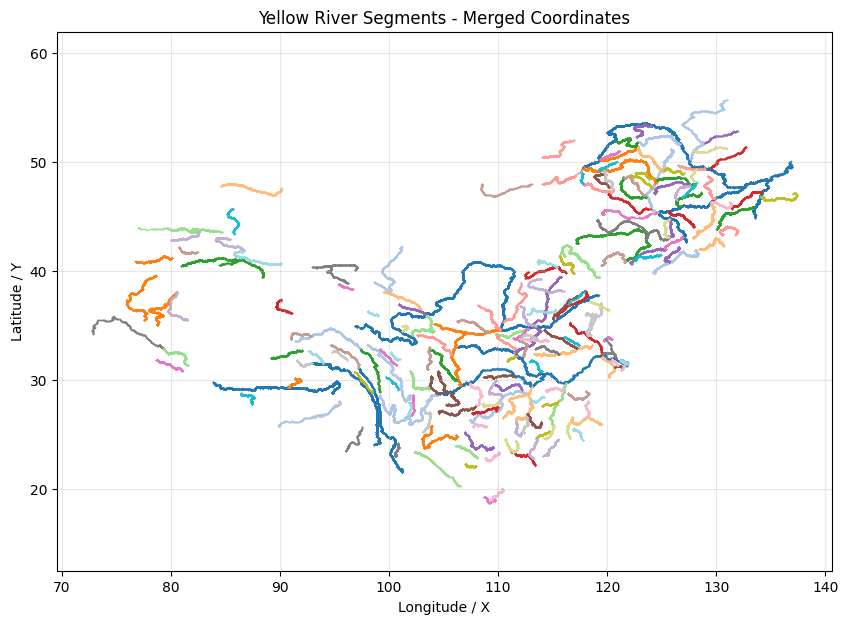

In [57]:
# 绘制所有黄河分段的散点图
import matplotlib.pyplot as plt
import matplotlib.cm as cm

if df_huang_all.empty:
    raise ValueError('df_huang_all 为空，请先确认已筛选到黄河数据。')

plot_df = df_plot.reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 7))

cmap = cm.get_cmap('tab20', max(len(plot_df), 1))

for idx, row in plot_df.iterrows():
    # 使用合并去重后的坐标列表
    pos = row.get('pos_list_meters')
    if not isinstance(pos, list) or len(pos) == 0:
        continue

    x = [p[0] for p in pos]
    y = [p[1] for p in pos]

    ax.scatter(
        x, y,
        s=1,                 # 点大小
        alpha=0.85,
        color=cmap(idx),
        label=f'segment_{idx + 1} (n={len(pos)})',
        marker='o',           # 可选：'.'、'o'、'^' 等
        linewidths=0
    )

ax.set_xlabel('Longitude / X')
ax.set_ylabel('Latitude / Y')
ax.set_title('Yellow River Segments - Merged Coordinates')
ax.axis('equal')
ax.grid(alpha=0.3)
# ax.legend(loc='best', fontsize=8, markerscale=5, frameon=True)
plt.show()